# Time-TRUST vs Full TRUST agregado — exploración de ranking agreement

Este notebook explora la tabla generada por `scripts/ranking_agreement_table.py`, filtrando la comparación principal:

```text
Full TRUST aggregated selection  vs  Time-TRUST selection
```

El objetivo aquí **no** es analizar performance todavía, sino inspeccionar si el ranking directo de Time-TRUST se parece al ranking inducido por Full TRUST después de agregarlo a sensores o ventanas.

## 0. Configuración

Antes de correr este notebook, deberían existir estos archivos:

```bash
python scripts/fulltrust_aggregate_rankings.py \
  --results-root results \
  --processed-root datasets/processed \
  --baselines-root mlp_baselines \
  --full-mode-contains mlp_rebuild__capped \
  --verbose

python scripts/ranking_agreement_table.py \
  --baselines-root mlp_baselines \
  --out-csv tables/ranking_agreement_fulltrust_vs_all.csv \
  --out-json tables/ranking_agreement_fulltrust_vs_all_summary.json \
  --verbose
```

In [2]:
from __future__ import annotations

from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

CSV_PATH = Path("tables/ranking_agreement_fulltrust_vs_all.csv")
JSON_SUMMARY_PATH = Path("tables/ranking_agreement_fulltrust_vs_all_summary.json")

CSV_PATH

PosixPath('tables/ranking_agreement_fulltrust_vs_all.csv')

## 1. Cargar la tabla completa

In [3]:
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"No encontré {CSV_PATH}. Primero corre scripts/ranking_agreement_table.py."
    )

df = pd.read_csv(CSV_PATH)

# Convertir columnas métricas a numérico por seguridad.
metric_cols = [
    "spearman", "kendall", "rank_mae", "rank_mae_norm", "rank_rmse",
    "overlap_at_1", "overlap_at_3", "overlap_at_5", "overlap_at_10",
]
for c in metric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("Rows:", len(df))
print("Comparators:", sorted(df["comparator"].dropna().unique().tolist()))
print("Group modes:", sorted(df["group_mode"].dropna().unique().tolist()))

df.head()

Rows: 90
Comparators: ['randomavg', 'timetrust_selection', 'weights']
Group modes: ['sensors', 'windows']


,dataset,window_tag,hidden_tag,group_mode,reference,comparator,n_groups,spearman,kendall,overlap_at_1,overlap_at_3,overlap_at_5,overlap_at_10,rank_mae,rank_mae_norm,rank_rmse,reference_file,comparator_file
0,FAKE_DATASET,W10_step1,h10,sensors,fulltrust_agg_selection,randomavg,5,0.800000,0.600000,0.0,0.666667,1.0,NaN,0.8,0.200000,0.894427,mlp_baselines/FAKE_DATASET/W10_step1/h10/rankings/ranking_sensors_fulltrust_agg_selection.json,mlp_baselines/FAKE_DATASET/W10_step1/h10/rankings/ranking_sensors_randomavg.json
1,FAKE_DATASET,W10_step1,h10,sensors,fulltrust_agg_selection,timetrust_selection,5,0.200000,0.200000,0.0,0.666667,1.0,NaN,1.6,0.400000,1.788854,mlp_baselines/FAKE_DATASET/W10_step1/h10/rankings/ranking_sensors_fulltrust_agg_selection.json,mlp_baselines/FAKE_DATASET/W10_step1/h10/rankings/ranking_sensors_timetrust_selection.json
2,FAKE_DATASET,W10_step1,h10,sensors,fulltrust_agg_selection,weights,5,0.000000,-0.200000,1.0,0.333333,1.0,NaN,1.6,0.400000,2.000000,mlp_baselines/FAKE_DATASET/W10_step1/h10/rankings/ranking_sensors_fulltrust_agg_selection.json,mlp_baselines/FAKE_DATASET/W10_step1/h10/rankings/ranking_sensors_weights.json
3,FAKE_DATASET,W10_step1,h10,windows,fulltrust_agg_selection,randomavg,10,0.503030,0.333333,0.0,0.666667,0.8,1.0,2.4,0.266667,2.863564,mlp_baselines/FAKE_DATASET/W10_step1/h10/rankings/ranking_windows_fulltrust_agg_selection.json,mlp_baselines/FAKE_DATASET/W10_step1/h10/rankings/ranking_windows_randomavg.json
4,FAKE_DATASET,W10_step1,h10,windows,fulltrust_agg_selection,timetrust_selection,10,0.612121,0.422222,0.0,0.666667,0.8,1.0,2.2,0.244444,2.529822,mlp_baselines/FAKE_DATASET/W10_step1/h10/rankings/ranking_windows_fulltrust_agg_selection.json,mlp_baselines/FAKE_DATASET/W10_step1/h10/rankings/ranking_windows_timetrust_selection.json


In [4]:
# Drop rows with dataset == "FAKE_DATASET" from df and tt (if tt exists)
removed_df = int(df["dataset"].eq("FAKE_DATASET").sum())
if removed_df:
    df = df[~df["dataset"].eq("FAKE_DATASET")].reset_index(drop=True)

removed_tt = None
if "tt" in globals():
    removed_tt = int(tt["dataset"].eq("FAKE_DATASET").sum())
    if removed_tt:
        tt = tt[~tt["dataset"].eq("FAKE_DATASET")].reset_index(drop=True)

print(f"Removed {removed_df} rows from df.")
if removed_tt is not None:
    print(f"Removed {removed_tt} rows from tt.")
print("New lengths -> df:", len(df), "tt:", len(tt) if "tt" in globals() else "N/A")

Removed 18 rows from df.
New lengths -> df: 72 tt: N/A


## 2. Filtrar comparación principal: Time-TRUST vs Full TRUST agregado

In [5]:
tt = df[df["comparator"].eq("timetrust_selection")].copy()

# Orden útil para inspección.
hidden_order = {"h10": 0, "h10_10": 1, "h10_10_10": 2}
tt["hidden_order"] = tt["hidden_tag"].map(hidden_order).fillna(999).astype(int)
tt = tt.sort_values(["dataset", "window_tag", "hidden_order", "group_mode"]).drop(columns=["hidden_order"])

print("Rows Time-TRUST:", len(tt))
tt[[
    "dataset", "window_tag", "hidden_tag", "group_mode", "n_groups",
    "spearman", "kendall", "overlap_at_1", "overlap_at_3", "overlap_at_5", "overlap_at_10",
    "rank_mae_norm"
]]

Rows Time-TRUST: 24


,dataset,window_tag,hidden_tag,group_mode,n_groups,spearman,kendall,overlap_at_1,overlap_at_3,overlap_at_5,overlap_at_10,rank_mae_norm
1,FD001,W30_step1,h10,sensors,15,0.778571,0.619048,0.0,1.000000,0.6,0.8,0.161905
4,FD001,W30_step1,h10,windows,30,0.422469,0.305747,0.0,0.333333,0.2,0.6,0.255172
7,FD001,W30_step1,h10_10,sensors,15,0.617857,0.447619,0.0,0.333333,0.6,0.9,0.219048
10,FD001,W30_step1,h10_10,windows,30,0.310790,0.250575,0.0,0.333333,0.4,0.5,0.248276
13,FD001,W30_step1,h10_10_10,sensors,15,0.467857,0.371429,0.0,0.333333,0.2,0.8,0.266667
16,FD001,W30_step1,h10_10_10,windows,30,0.058509,0.062069,0.0,0.333333,0.4,0.6,0.305747
19,FD002,W30_step1,h10,sensors,21,0.688312,0.514286,1.0,1.000000,0.8,0.7,0.152381
22,FD002,W30_step1,h10,windows,30,0.296997,0.204598,0.0,0.000000,0.0,0.4,0.280460
25,FD002,W30_step1,h10_10,sensors,21,0.955844,0.847619,1.0,0.333333,0.8,1.0,0.071429
28,FD002,W30_step1,h10_10,windows,30,0.523026,0.379310,0.0,0.333333,0.4,0.5,0.229885


## 3. Tablas resumen por granularidad

Lectura rápida:

- `spearman` y `kendall`: más alto es mejor.
- `overlap_at_k`: proporción de coincidencia entre los top-k grupos.
- `rank_mae_norm`: desplazamiento medio normalizado de posiciones; más bajo es mejor.

In [6]:
summary_by_mode = (
    tt.groupby("group_mode")
    .agg(
        n=("spearman", "size"),
        mean_spearman=("spearman", "mean"),
        median_spearman=("spearman", "median"),
        mean_kendall=("kendall", "mean"),
        mean_overlap_at_3=("overlap_at_3", "mean"),
        mean_overlap_at_5=("overlap_at_5", "mean"),
        mean_overlap_at_10=("overlap_at_10", "mean"),
        mean_rank_mae_norm=("rank_mae_norm", "mean"),
    )
    .reset_index()
)

summary_by_mode

,group_mode,n,mean_spearman,median_spearman,mean_kendall,mean_overlap_at_3,mean_overlap_at_5,mean_overlap_at_10,mean_rank_mae_norm
0,sensors,12,0.710870,0.753266,0.559524,0.416667,0.633333,0.816667,0.175595
1,windows,12,0.241824,0.303893,0.185441,0.250000,0.250000,0.425000,0.282567


In [7]:
summary_by_dataset_mode = (
    tt.groupby(["dataset", "group_mode"])
    .agg(
        n=("spearman", "size"),
        mean_spearman=("spearman", "mean"),
        mean_kendall=("kendall", "mean"),
        mean_overlap_at_3=("overlap_at_3", "mean"),
        mean_overlap_at_5=("overlap_at_5", "mean"),
        mean_rank_mae_norm=("rank_mae_norm", "mean"),
    )
    .reset_index()
    .sort_values(["dataset", "group_mode"])
)

summary_by_dataset_mode

,dataset,group_mode,n,mean_spearman,mean_kendall,mean_overlap_at_3,mean_overlap_at_5,mean_rank_mae_norm
0,FD001,sensors,3,0.621429,0.479365,0.555556,0.466667,0.215873
1,FD001,windows,3,0.263923,0.206130,0.333333,0.333333,0.269732
2,FD002,sensors,3,0.813420,0.660317,0.555556,0.733333,0.125397
3,FD002,windows,3,0.248350,0.180077,0.111111,0.133333,0.296552
4,FD003,sensors,3,0.696078,0.533333,0.222222,0.600000,0.194444
5,FD003,windows,3,0.377382,0.302682,0.444444,0.400000,0.227586
6,FD004,sensors,3,0.712554,0.565079,0.333333,0.733333,0.166667
7,FD004,windows,3,0.077642,0.052874,0.111111,0.133333,0.336398


## 4. Heatmaps simples

Cada celda es una configuración `dataset × architecture`. Se generan heatmaps separados para sensores y ventanas.

In [8]:
def _ordered_pivot(data: pd.DataFrame, metric: str, group_mode: str) -> pd.DataFrame:
    sub = data[data["group_mode"].eq(group_mode)].copy()
    if sub.empty:
        return pd.DataFrame()
    p = sub.pivot_table(index="dataset", columns="hidden_tag", values=metric, aggfunc="mean")
    # Orden estable si existen estas columnas.
    cols = [c for c in ["h10", "h10_10", "h10_10_10"] if c in p.columns]
    other_cols = [c for c in p.columns if c not in cols]
    p = p[cols + other_cols]
    return p.sort_index()


def plot_heatmap_table(data: pd.DataFrame, metric: str, group_mode: str, *, vmin=None, vmax=None, cmap="viridis"):
    p = _ordered_pivot(data, metric, group_mode)
    if p.empty:
        print(f"No hay datos para group_mode={group_mode}")
        return None

    arr = p.to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(max(5, 1.2 * p.shape[1]), max(3, 0.55 * p.shape[0] + 1)))
    im = ax.imshow(arr, aspect="auto", interpolation="nearest", vmin=vmin, vmax=vmax, cmap=cmap)

    ax.set_xticks(np.arange(p.shape[1]))
    ax.set_xticklabels(p.columns.tolist(), rotation=45, ha="right")
    ax.set_yticks(np.arange(p.shape[0]))
    ax.set_yticklabels(p.index.tolist())
    ax.set_title(f"{metric} | Aggregated Full TRUST vs Time-Trust | {group_mode}")

    # Anotar valores.
    for i in range(p.shape[0]):
        for j in range(p.shape[1]):
            val = arr[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)
            else:
                ax.text(j, i, "NA", ha="center", va="center", fontsize=9)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel(metric, rotation=270, labelpad=12)
    fig.tight_layout()
    plt.show()
    return fig

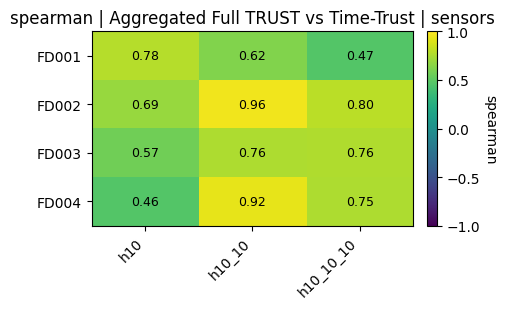

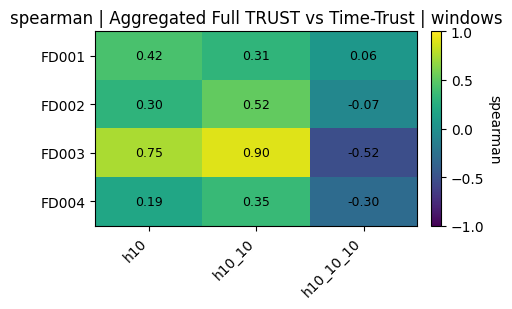

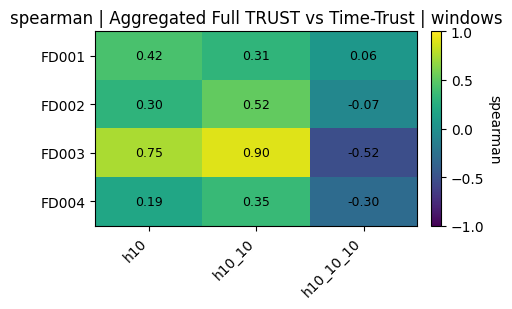

In [9]:
# Spearman: agreement global del ranking. Rango típico [-1, 1].
plot_heatmap_table(tt, "spearman", "sensors", vmin=-1, vmax=1)
plot_heatmap_table(tt, "spearman", "windows", vmin=-1, vmax=1)

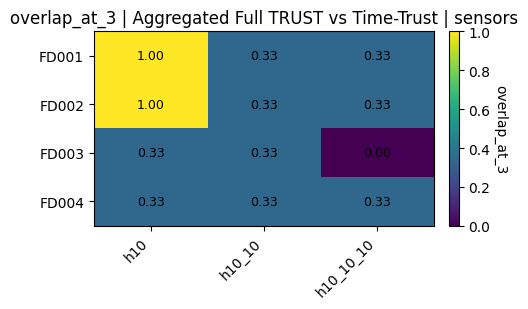

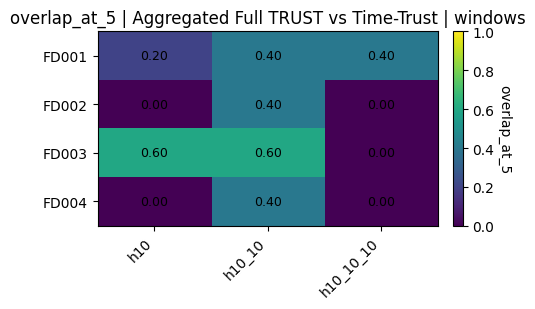

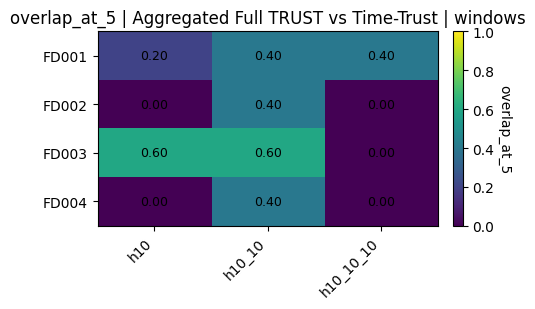

In [10]:
# Overlap@k: top-k compartido. Para sensores suele interesar @3/@5; para ventanas @5/@10.
plot_heatmap_table(tt, "overlap_at_3", "sensors", vmin=0, vmax=1)
plot_heatmap_table(tt, "overlap_at_5", "windows", vmin=0, vmax=1)

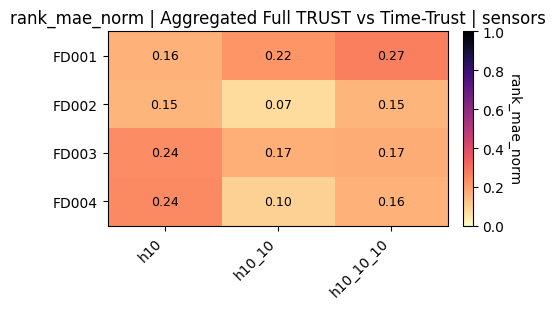

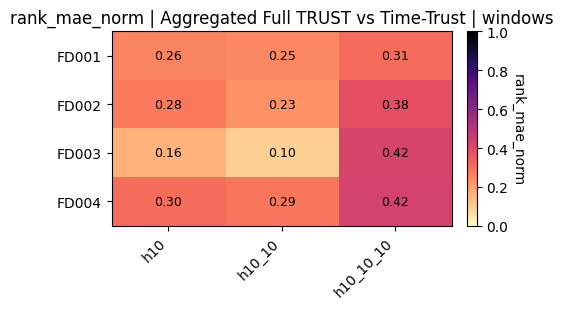

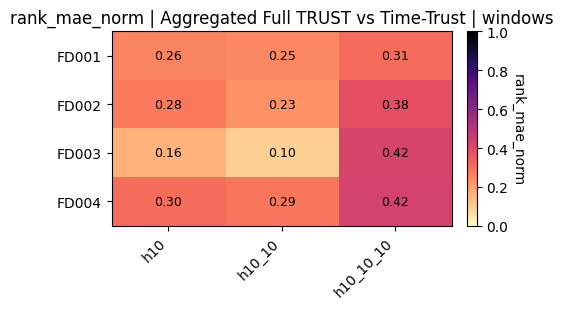

In [11]:
# Rank MAE normalizado: más bajo es mejor.
plot_heatmap_table(tt, "rank_mae_norm", "sensors", vmin=0, vmax=1, cmap="magma_r")
plot_heatmap_table(tt, "rank_mae_norm", "windows", vmin=0, vmax=1, cmap="magma_r")

In [18]:
def plot_heatmap_table_sensors_windows(
    data: pd.DataFrame,
    metric: str,
    *,
    vmin=None,
    vmax=None,
    cmap="viridis",
    title_prefix="Aggregated Full TRUST vs Time-TRUST",
):
    pivots = {
        "sensors": _ordered_pivot(data, metric, "sensors"),
        "windows": _ordered_pivot(data, metric, "windows"),
    }

    if pivots["sensors"].empty and pivots["windows"].empty:
        print(f"No hay datos para metric={metric}")
        return None

    # Dimensiones robustas.
    max_cols = max([p.shape[1] for p in pivots.values() if not p.empty], default=1)
    total_rows = sum([p.shape[0] for p in pivots.values() if not p.empty])

    fig_h = max(7.7, 0.55 * total_rows + 2.2)
    fig_w = max(6, 1.25 * max_cols + 2.0)

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(5, 7.7),
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes)

    for ax, group_mode in zip(axes, ["sensors", "windows"]):
        p = pivots[group_mode]

        if p.empty:
            ax.axis("off")
            ax.set_title(f"{group_mode}: no data")
            continue

        arr = p.to_numpy(dtype=float)

        im = ax.imshow(
            arr,
            aspect="auto",
            interpolation="nearest",
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
        )

        ax.set_xticks(np.arange(p.shape[1]))
        ax.set_xticklabels(p.columns.tolist(), rotation=45, ha="right")

        ax.set_yticks(np.arange(p.shape[0]))
        ax.set_yticklabels(p.index.tolist())

        ax.set_title(f"{metric} | {title_prefix} | {group_mode}")

        # Anotar valores.
        for i in range(p.shape[0]):
            for j in range(p.shape[1]):
                val = arr[i, j]
                if np.isfinite(val):
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)
                else:
                    ax.text(j, i, "NA", ha="center", va="center", fontsize=9)

        # Colorbar individual por subplot.
        cbar = fig.colorbar(
            im,
            ax=ax,
            fraction=0.046,
            pad=0.04,
        )
        cbar.ax.set_ylabel(metric, rotation=270, labelpad=12)

    plt.show()
    return fig

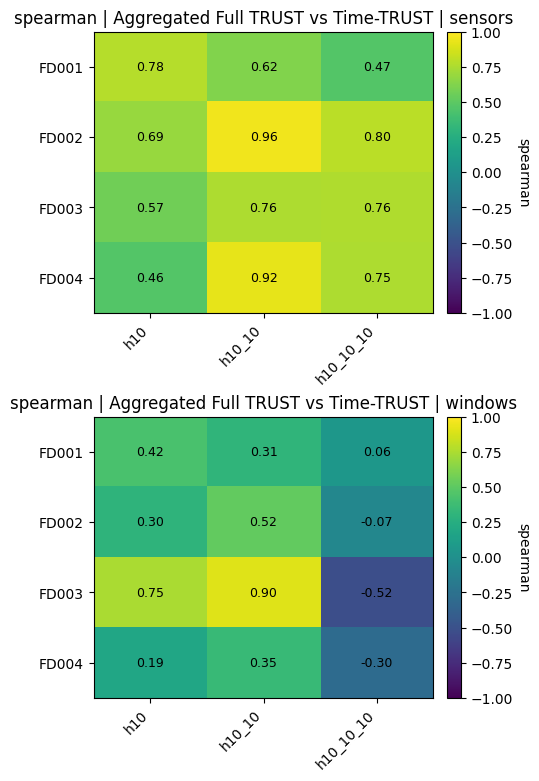

In [19]:
_ = plot_heatmap_table_sensors_windows(
    tt,
    metric="spearman",
    vmin=-1,
    vmax=1,
    cmap="viridis",
)

In [20]:
# Summary table: Time-TRUST vs Aggregated Full TRUST

summary_metrics = ["spearman", "kendall", "rank_mae_norm"]

summary_table = (
    tt
    .groupby("group_mode", as_index=False)
    .agg(
        n_configs=("spearman", "count"),
        spearman_mean=("spearman", "mean"),
        spearman_std=("spearman", "std"),
        spearman_min=("spearman", "min"),
        spearman_max=("spearman", "max"),
        kendall_mean=("kendall", "mean"),
        rank_mae_norm_mean=("rank_mae_norm", "mean"),
    )
)

# Orden más legible
mode_order = pd.CategoricalDtype(categories=["sensors", "windows"], ordered=True)
summary_table["group_mode"] = summary_table["group_mode"].astype(mode_order)
summary_table = summary_table.sort_values("group_mode")

# Redondear para paper/exploración
summary_table_rounded = summary_table.copy()
num_cols = summary_table_rounded.select_dtypes(include="number").columns
summary_table_rounded[num_cols] = summary_table_rounded[num_cols].round(3)

display(summary_table_rounded)

,group_mode,n_configs,spearman_mean,spearman_std,spearman_min,spearman_max,kendall_mean,rank_mae_norm_mean
0,sensors,12,0.711,0.157,0.465,0.956,0.560,0.176
1,windows,12,0.242,0.409,-0.523,0.905,0.185,0.283


In [23]:
out_path = "tables/ranking_agreement_timetrust_vs_fulltrust_summary_by_mode.csv"
summary_table_rounded.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: tables/ranking_agreement_timetrust_vs_fulltrust_summary_by_mode.csv
